<a href="https://colab.research.google.com/github/Rohil121/bharat-portfolio-lab/blob/v0.3-robustness-testing/notebooks/03_robustness_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bharat Portfolio Lab — Robustness Testing

## Version v0.3

This notebook evaluates whether the Adaptive Barbell strategy remains reliable when the testing period, parameters and modelling assumptions change.

### Planned tests

- Development-period versus out-of-sample performance
- Momentum, volatility and trend-window sensitivity
- Transaction-cost stress testing
- Rolling return and risk analysis
- Market-regime performance
- Strategy robustness scoring

The objective is not to find the historically best parameter combination. The objective is to identify whether reasonable alternative assumptions produce broadly consistent results.

## 1. Environment Setup

This section prepares the Python environment for reproducible robustness testing of the Adaptive Barbell strategy.

In [1]:
%pip install -q yfinance

In [2]:
import sys
from importlib.metadata import version
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display settings
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("v0.3 environment setup complete.")
print("-" * 45)
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {version('matplotlib')}")
print(f"yfinance: {version('yfinance')}")
print(f"Random seed: {RANDOM_SEED}")

v0.3 environment setup complete.
---------------------------------------------
Python: 3.12.13
pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
yfinance: 0.2.66
Random seed: 42


## 2. Portfolio and Robustness-Test Configuration

The v0.3 analysis retains the same India 10 flagship portfolio so that the strategy remains comparable with version v0.2.

The historical period is divided into:

- **Development period:** used to examine and establish the strategy rules.
- **Out-of-sample period:** used to evaluate the frozen strategy on later data.

The out-of-sample results will receive greater importance than the full-period results.

In [3]:
# ---------------------------------------------------------
# India 10 Adaptive Barbell portfolio
# ---------------------------------------------------------

portfolio = pd.DataFrame(
    {
        "Company": [
            "HDFC Bank",
            "Tata Consultancy Services",
            "Hindustan Unilever",
            "Sun Pharmaceutical Industries",
            "Power Grid Corporation of India",
            "Bharti Airtel",
            "Larsen & Toubro",
            "Mahindra & Mahindra",
            "Bharat Electronics",
            "Trent",
        ],
        "Ticker": [
            "HDFCBANK.NS",
            "TCS.NS",
            "HINDUNILVR.NS",
            "SUNPHARMA.NS",
            "POWERGRID.NS",
            "BHARTIARTL.NS",
            "LT.NS",
            "M&M.NS",
            "BEL.NS",
            "TRENT.NS",
        ],
        "Sector": [
            "Financial Services",
            "Information Technology",
            "Consumer Staples",
            "Healthcare",
            "Utilities",
            "Telecommunication",
            "Industrials",
            "Automobile",
            "Defence Electronics",
            "Consumer Retail",
        ],
        "Strategy Bucket": [
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
        ],
    }
)

portfolio["Initial Weight"] = 1 / len(portfolio)

portfolio_tickers = portfolio["Ticker"].tolist()

resilient_tickers = portfolio.loc[
    portfolio["Strategy Bucket"] == "Resilient Compounder",
    "Ticker",
].tolist()

growth_tickers = portfolio.loc[
    portfolio["Strategy Bucket"] == "Growth Leader",
    "Ticker",
].tolist()


# ---------------------------------------------------------
# Market and portfolio assumptions
# ---------------------------------------------------------

BENCHMARK_TICKER = "^NSEI"
BENCHMARK_NAME = "Nifty 50"

INITIAL_CAPITAL = 1_000_000  # ₹10 lakh
TRADING_DAYS = 252
RISK_FREE_RATE = 0.065

TRANSACTION_COST_RATE = 0.0015


# ---------------------------------------------------------
# Historical testing periods
# ---------------------------------------------------------

DATA_START_DATE = "2016-01-01"

DEVELOPMENT_START_DATE = pd.Timestamp("2016-01-01")
OUT_OF_SAMPLE_START_DATE = pd.Timestamp("2022-01-01")

DOWNLOAD_END_DATE = (
    pd.Timestamp.today().normalize()
    + pd.Timedelta(days=1)
)


# ---------------------------------------------------------
# Frozen v0.2 strategy parameters
# ---------------------------------------------------------

BASE_MOMENTUM_LOOKBACK = 126
BASE_VOLATILITY_LOOKBACK = 63
BASE_TREND_LOOKBACK = 200

BASE_FULL_EQUITY_EXPOSURE = 1.00
BASE_DEFENSIVE_EQUITY_EXPOSURE = 0.70


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

assert len(portfolio) == 10
assert portfolio["Ticker"].is_unique
assert len(resilient_tickers) == 5
assert len(growth_tickers) == 5
assert np.isclose(portfolio["Initial Weight"].sum(), 1.0)

assert DEVELOPMENT_START_DATE < OUT_OF_SAMPLE_START_DATE
assert 0 <= BASE_DEFENSIVE_EQUITY_EXPOSURE <= 1
assert BASE_FULL_EQUITY_EXPOSURE == 1.0


print("v0.3 configuration completed.")
print("-" * 55)
print(f"Portfolio holdings: {len(portfolio)}")
print(f"Data begins: {DATA_START_DATE}")
print(
    "Development period:",
    f"{DEVELOPMENT_START_DATE.date()} to "
    f"{(OUT_OF_SAMPLE_START_DATE - pd.Timedelta(days=1)).date()}",
)
print(
    "Out-of-sample period:",
    f"{OUT_OF_SAMPLE_START_DATE.date()} onward",
)
print(f"Initial capital: ₹{INITIAL_CAPITAL:,.0f}")
print(f"Base transaction cost: {TRANSACTION_COST_RATE:.2%}")

display(portfolio)

v0.3 configuration completed.
-------------------------------------------------------
Portfolio holdings: 10
Data begins: 2016-01-01
Development period: 2016-01-01 to 2021-12-31
Out-of-sample period: 2022-01-01 onward
Initial capital: ₹1,000,000
Base transaction cost: 0.15%


,Company,Ticker,Sector,Strategy Bucket,Initial Weight
0,HDFC Bank,HDFCBANK.NS,Financial Services,Resilient Compounder,0.1000
1,Tata Consultancy Services,TCS.NS,Information Technology,Resilient Compounder,0.1000
2,Hindustan Unilever,HINDUNILVR.NS,Consumer Staples,Resilient Compounder,0.1000
3,Sun Pharmaceutical Industries,SUNPHARMA.NS,Healthcare,Resilient Compounder,0.1000
4,Power Grid Corporation of India,POWERGRID.NS,Utilities,Resilient Compounder,0.1000
5,Bharti Airtel,BHARTIARTL.NS,Telecommunication,Growth Leader,0.1000
6,Larsen & Toubro,LT.NS,Industrials,Growth Leader,0.1000
7,Mahindra & Mahindra,M&M.NS,Automobile,Growth Leader,0.1000
8,Bharat Electronics,BEL.NS,Defence Electronics,Growth Leader,0.1000
9,Trent,TRENT.NS,Consumer Retail,Growth Leader,0.1000


## 3. Extended Historical Market Data

This section downloads adjusted daily closing prices for the India 10 portfolio and the Nifty 50 benchmark from 2016 onward.

The longer dataset allows the strategy to be tested across multiple market conditions and divided into development and out-of-sample periods.

In [5]:
# ---------------------------------------------------------
# Download adjusted historical prices
# ---------------------------------------------------------

all_tickers = portfolio_tickers + [BENCHMARK_TICKER]

raw_market_data = yf.download(
    tickers=all_tickers,
    start=DATA_START_DATE,
    end=DOWNLOAD_END_DATE.strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    threads=True,
)

if raw_market_data.empty:
    raise ValueError(
        "No market data was downloaded."
    )


# ---------------------------------------------------------
# Extract closing prices
# ---------------------------------------------------------

if isinstance(raw_market_data.columns, pd.MultiIndex):

    if "Close" not in raw_market_data.columns.get_level_values(0):
        raise ValueError(
            "Closing-price data was not returned."
        )

    close_prices = raw_market_data["Close"].copy()

else:

    close_prices = raw_market_data[["Close"]].copy()
    close_prices.columns = all_tickers


# ---------------------------------------------------------
# Arrange and inspect the data
# ---------------------------------------------------------

close_prices = (
    close_prices
    .reindex(columns=all_tickers)
    .sort_index()
)

missing_before_cleaning = (
    close_prices
    .isna()
    .sum()
    .rename("Missing Observations")
)

completely_missing_tickers = (
    close_prices.columns[
        close_prices.isna().all()
    ]
    .tolist()
)

if completely_missing_tickers:
    raise ValueError(
        "No historical data was found for: "
        + ", ".join(completely_missing_tickers)
    )


# Fill only short gaps, then retain fully aligned observations
close_prices = (
    close_prices
    .ffill(limit=3)
    .dropna()
)


# ---------------------------------------------------------
# Separate portfolio and benchmark data
# ---------------------------------------------------------

stock_prices = (
    close_prices[portfolio_tickers]
    .copy()
)

benchmark_prices = (
    close_prices[[BENCHMARK_TICKER]]
    .rename(
        columns={
            BENCHMARK_TICKER: BENCHMARK_NAME
        }
    )
)


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

assert not close_prices.empty, \
    "The cleaned price dataset is empty."

assert stock_prices.shape[1] == 10, \
    "Data is not available for all 10 portfolio holdings."

assert stock_prices.isna().sum().sum() == 0, \
    "Missing values remain in the stock-price dataset."

assert benchmark_prices.isna().sum().sum() == 0, \
    "Missing values remain in the benchmark dataset."

assert stock_prices.index.equals(
    benchmark_prices.index
), "Stock and benchmark dates are not aligned."

assert close_prices.index.is_monotonic_increasing, \
    "Market dates are not arranged chronologically."

assert close_prices.index.min() < OUT_OF_SAMPLE_START_DATE, \
    "Insufficient data exists before the out-of-sample period."


print("Extended historical data downloaded successfully.")
print("-" * 60)
print(
    f"Requested start date: "
    f"{pd.Timestamp(DATA_START_DATE).date()}"
)
print(
    f"First common observation: "
    f"{close_prices.index.min().date()}"
)
print(
    f"Latest observation: "
    f"{close_prices.index.max().date()}"
)
print(
    f"Total trading observations: "
    f"{len(close_prices):,}"
)
print(
    f"Development observations: "
    f"{(close_prices.index < OUT_OF_SAMPLE_START_DATE).sum():,}"
)
print(
    f"Out-of-sample observations: "
    f"{(close_prices.index >= OUT_OF_SAMPLE_START_DATE).sum():,}"
)

print("\nMissing observations before cleaning:")
display(
    missing_before_cleaning.to_frame()
)

print("\nLatest adjusted closing prices:")
display(
    close_prices.tail()
)

Extended historical data downloaded successfully.
------------------------------------------------------------
Requested start date: 2016-01-01
First common observation: 2016-01-04
Latest observation: 2026-07-30
Total trading observations: 2,614
Development observations: 1,481
Out-of-sample observations: 1,133

Missing observations before cleaning:


,Missing Observations
Ticker,
HDFCBANK.NS,0
TCS.NS,0
HINDUNILVR.NS,0
SUNPHARMA.NS,0
POWERGRID.NS,0
BHARTIARTL.NS,0
LT.NS,0
M&M.NS,0
BEL.NS,0



Latest adjusted closing prices:


Ticker,HDFCBANK.NS,TCS.NS,HINDUNILVR.NS,SUNPHARMA.NS,POWERGRID.NS,BHARTIARTL.NS,LT.NS,M&M.NS,BEL.NS,TRENT.NS,^NSEI
Date,,,,,,,,,,,
2026-07-24,742.8000,"2,254.3000","2,145.0000","1,941.1000",288.2000,"1,898.2000","3,785.6001","3,161.3999",405.0000,"2,890.5000","23,767.4492"
2026-07-27,739.5500,"2,295.6001","2,174.6001","1,973.7000",288.8500,"1,905.3000","3,806.0000","3,238.6001",407.1500,"2,938.3000","23,995.9492"
2026-07-28,735.4000,"2,398.0000","2,022.7000","1,976.7000",285.3000,"1,901.8000","3,832.0000","3,271.2000",389.0000,"2,930.7000","23,985.3496"
2026-07-29,748.2000,"2,446.6001","2,117.8000","1,989.9000",282.8500,"1,950.2000","3,931.3999","3,221.8000",387.5500,"3,005.2000","24,250.1992"
2026-07-30,753.9500,"2,431.8000","2,107.8999","2,001.1000",285.7000,"1,956.8000","3,937.7000","3,283.7000",384.9000,"2,999.2000","24,317.1504"


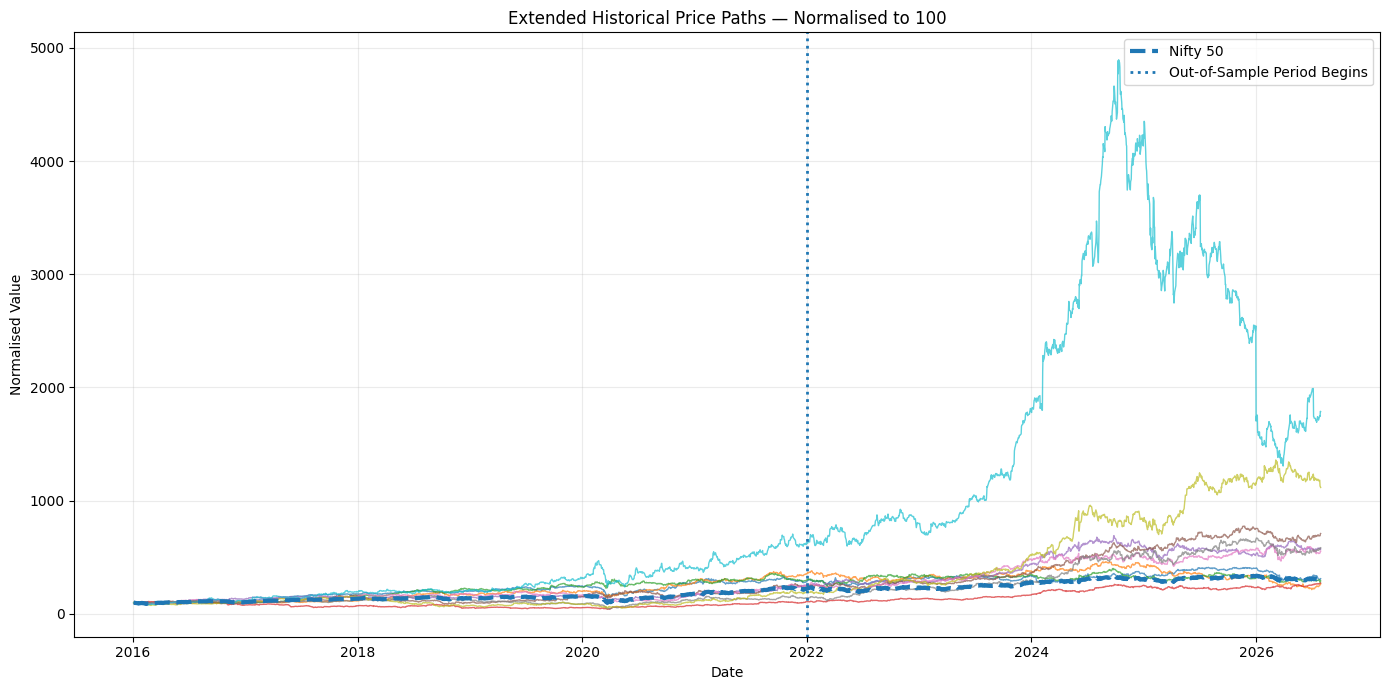

In [6]:
# ---------------------------------------------------------
# Visual validation of the extended dataset
# ---------------------------------------------------------

normalised_prices = (
    close_prices
    .div(close_prices.iloc[0])
    .mul(100)
)

plt.figure(figsize=(14, 7))

for ticker in portfolio_tickers:

    plt.plot(
        normalised_prices.index,
        normalised_prices[ticker],
        linewidth=1,
        alpha=0.70,
    )

plt.plot(
    normalised_prices.index,
    normalised_prices[BENCHMARK_TICKER],
    linewidth=3,
    linestyle="--",
    label=BENCHMARK_NAME,
)

plt.axvline(
    OUT_OF_SAMPLE_START_DATE,
    linewidth=2,
    linestyle=":",
    label="Out-of-Sample Period Begins",
)

plt.title(
    "Extended Historical Price Paths — Normalised to 100"
)
plt.xlabel("Date")
plt.ylabel("Normalised Value")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()